In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import cooler
import cooltools
from cooltools import insulation

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [3]:
data_dir = '/tank/projects/kashuk_sirt6_hic/bal_comb_10k/'

In [4]:
wt_clr = cooler.Cooler(f'{data_dir}/bal_sampled_WT_10k.cool')
old_clr = cooler.Cooler(f'{data_dir}/bal_sampled_old_10k.cool')
ko_clr = cooler.Cooler(f'{data_dir}/bal_sampled_KO_10k.cool')

### Call TAD boundaries

In [5]:
resolution = 10000
windows = [5*resolution]
adl_insulation = insulation(wt_clr, windows, verbose=True, ignore_diags=1)
old_insulation = insulation(old_clr, windows, verbose=True, ignore_diags=1)
ko_insulation = insulation(ko_clr, windows, verbose=True, ignore_diags=1)

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root:Processing region chr7
INFO:root:Processing region chr8
INFO:root:Processing region chr9
INFO:root:Processing region chr10
INFO:root:Processing region chr11
INFO:root:Processing region chr12
INFO:root:Processing region chr13
INFO:root:Processing region chr14
INFO:root:Processing region chr15
INFO:root:Processing region chr16
INFO:root:Processing region chr17
INFO:root:Processing region chr18
INFO:root:Processing region chr19
INFO:root:Processing region chrX
INFO:root:Processing region chrY
INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root

In [6]:
adl_insulation.head(5)

,chrom,start,end,region,is_bad_bin,log2_insulation_score_50000,n_valid_pixels_50000,boundary_strength_50000,is_boundary_50000
0,chr1,0,10000,chr1,False,NaN,4.0,NaN,False
1,chr1,10000,20000,chr1,False,NaN,9.0,NaN,False
2,chr1,20000,30000,chr1,False,NaN,14.0,NaN,False
3,chr1,30000,40000,chr1,False,NaN,19.0,NaN,False
4,chr1,40000,50000,chr1,False,NaN,24.0,NaN,False


In [68]:
import bioframe
import numpy as np
import pandas as pd

# constants
start, end = 1_000_000, 300_000_000
chromosomes = [f"chr{i}" for i in range(1,20)] + ["chrX","chrY"]
window = 50000   

def get_merged_boundaries(insulation_table, window=50000):
    """
    Given a insulation_table dataframe,
    returns a DataFrame of all (chrom, start, end) boundary pairs.
    """
    merged = []
    bs_col   = f"boundary_strength_{window}"
    flag_col = f"is_boundary_{window}"
    
    for chrom in chromosomes:
        region       = (chrom, start, end)
        ins_region   = bioframe.select(insulation_table, region)
        keep         = ins_region[~np.isnan(ins_region[bs_col])]
        keep         = keep[ keep[flag_col] ]
        
        if keep.shape[0] < 2:
            continue
        
        starts = keep["start"].to_numpy()
        ends   = keep["end"].to_numpy()
        ins_score = keep['log2_insulation_score_50000'].to_numpy()
        evens  = np.arange(1, len(starts), 2)  # 0‑based even indices
        
        # replace even positions with the corresponding end
        starts[evens] = ends[evens]
        
        # build the sliding pairs
        df_chr = pd.DataFrame({
            "chr":   chrom,
            "start": starts[:-1],
            "end":   starts[1:] - 1,
            "ins_score": ins_score[:-1],
        })
        merged.append(df_chr)
    
    return pd.concat(merged, ignore_index=True)

merged_adl = get_merged_boundaries(adl_insulation)
merged_old = get_merged_boundaries(old_insulation)
merged_ko  = get_merged_boundaries(ko_insulation)



In [8]:
merged_adl

,chr,start,end,ins_score
0,chr1,3150000,3669999,-0.740220
1,chr1,3670000,4069999,-0.503155
2,chr1,4070000,4569999,-0.972498
3,chr1,4570000,4759999,-0.714962
4,chr1,4760000,5089999,-0.456965
...,...,...,...,...
11497,chrX,167500000,168119999,-0.529751
11498,chrX,168120000,168679999,-0.210775
11499,chrX,168680000,168939999,-0.297133
11500,chrX,168940000,169329999,-0.110780


In [10]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    
	Wilcoxon rank sum test with continuity correction

data:  merged_adl$ins_score and merged_old$ins_score
W = 55068422, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  merged_adl$ins_score and merged_ko$ins_score
W = 64194246, p-value = 0.2628
alternative hypothesis: true location shift is not equal to 0




Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: Removed 1178 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


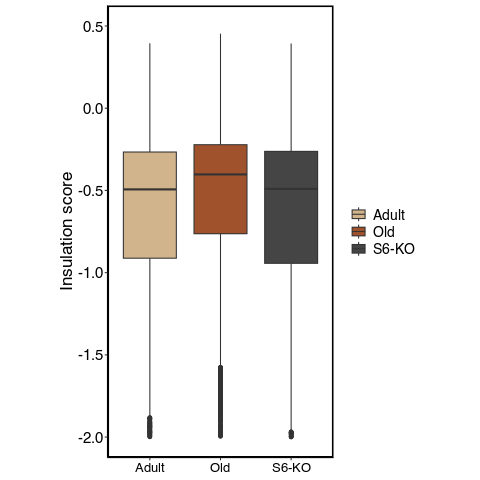

In [11]:
%%R

library(ggplot2)
library(dplyr)

merged_adl <- reticulate::py_eval("merged_adl")
merged_old <- reticulate::py_eval("merged_old")
merged_ko <- reticulate::py_eval("merged_ko")

merged_adl$condition <- "Adult"
merged_old$condition <- "Old"
merged_ko$condition  <- "S6-KO"

df_all <- bind_rows(merged_adl, merged_old, merged_ko)

p <- ggplot(df_all, aes(x = condition, y = ins_score, fill=condition)) +
  geom_boxplot() +
  ylim(-2, 0.5) +
  #geom_jitter(width = 0.15, alpha = 0.3, size = 0.8) +
  theme_classic() +
  labs(
    x = NULL,
    y = "Insulation score"
  ) + 
  scale_fill_manual(values=c('tan', 'sienna', 'gray27')) +
  theme(axis.text.x = element_text(size = 13, colour = 'black'),
        axis.text.y = element_text(size = 15, colour = 'black'),
        axis.title.y = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=14),
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 2/1)

print(p)
print(wilcox.test(merged_adl$ins_score, merged_old$ins_score))
print(wilcox.test(merged_adl$ins_score, merged_ko$ins_score))


#ggsave('TADs_ins_score.pdf', p, dpi=1200)

### Average TAD

In [12]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import coolpuppy
from coolpuppy import coolpup
import cooler

In [13]:
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)

### Calculate expected

In [23]:
from cooltools import expected_cis

CLRS = [wt_clr, old_clr, ko_clr]

results = [
    expected_cis(
        clr,
        ignore_diags=0,
        view_df=mm10_arms,
        chunksize=1_000_000,
        nproc=15
    )
    for clr in CLRS
]

expected_adl, expected_old, expected_ko = results

INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers


In [88]:
def prepare_tad_file(tad_file):
    """ Prepares the TAD file by selecting the necessary columns. """
    return tad_file[["chrom", "start", "end"]]

def create_average_tad_borders(tad_boundary_file, treatment_cooler, control_cooler, expected_contact_maps, map_resolution):
    """ 
    Constructs the average TAD self-border for both Hi-C cooler files.
    
    Args:
        tad_boundary_file: File containing TAD boundaries (columns: chrom, start, end).
        treatment_cooler: Cooler file for treatment conditions.
        control_cooler: Cooler file for control conditions.
        expected_contact_maps: List of expected contact maps.
        map_resolution: The resolution for analysis.
        
    Returns:
        average_borders: List of averaged TAD border pileups.
    """
    processed_tad_file = prepare_tad_file(tad_boundary_file)
    
    average_borders = []
    coolers = [treatment_cooler, control_cooler]
    
    for index, cooler in enumerate(coolers):
        coord_creator = coolpup.CoordCreator(processed_tad_file, resolution=map_resolution, features_format='bed', local=True, rescale_flank=1)
        
        # Generate pileup 
        pile_upper = coolpup.PileUpper(cooler, coord_creator, expected=expected_contact_maps[index], 
                                        view_df=mm10_arms, ignore_diags=0, 
                                        rescale_size=99, rescale=True)
        
        pileups_result = pile_upper.pileupsWithControl(nproc=10)
        average_borders.append((pileups_result.data)[0])  
    return average_borders

def create_plot_indices():
    """ Generates a list of x and y indices for visualization. """
    x_indices = []
    y_indices = []    
    x_initial = 32
    y_initial = 33    
    x_current = x_initial
    y_current = y_initial
    limit = 66
    for _ in range(33):
        while x_current < limit:
            x_indices.append(x_current)
            y_indices.append(y_current)
            x_current += 1
        y_current += 1
        x_initial += 1
        x_current = x_initial
    return x_indices, y_indices

def extract_plot_values(average_tad):
    """ Retrieves values from average TAD pileups using the generated plot indices. """
    x_indices, y_indices = create_plot_indices()
    
    first_condition_bp = [] 
    first_condition_data = average_tad[0]
    first_condition_data[first_condition_data == np.inf] = np.nan 
    
    for x, y in zip(y_indices, x_indices):
        first_condition_bp.append(np.log(first_condition_data)[x, y])
        
    second_condition_bp = [] 
    second_condition_data = average_tad[1]
    second_condition_data[second_condition_data == np.inf] = np.nan 
    
    for x, y in zip(y_indices, x_indices):
        second_condition_bp.append(np.log(second_condition_data)[x, y])
    
    return first_condition_bp, second_condition_bp

def visualize_ratio(stacks, vmin=-0.05, vmax=0.05):
    """ Visualizes the ratio of treatment/control TADs from the pileups. """
    sns.set_style("ticks")
    plt.rcParams['axes.facecolor'] = 'white'
    
    figure, axes = plt.subplots(1, 2,
                                figsize=(6, 7),  
                                dpi=350, 
                                gridspec_kw={'width_ratios': [1, 0.1]})

    x_indices, y_indices = create_plot_indices()

    # Compute the ratio 
    ratio = stacks[0] / stacks[1]
    ratio[ratio == np.inf] = np.nan  # Replace infinities with NaN
    
    image = axes[0].imshow(np.log(ratio), cmap='coolwarm', vmin=vmin, vmax=vmax)
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    plt.colorbar(image, cax=axes[1])
    axes[1].set_box_aspect(10)
    axes[1].set_ylabel("log2(mean intensity)")
    
    plt.tight_layout()

#### Old/Adult pileup

In [30]:
tad_file = merged_old.drop(columns=['ins_score']) 

tad_file.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_old, expected_adl]

av_tad_old = create_average_tad_borders(tad_file, old_clr, wt_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr9_p', 'chr9_p'): 550
INFO:coolpuppy:('chr8_p', 'chr8_p'): 486
INFO:coolpuppy:('chr10_p', 'chr10_p'): 527
INFO:coolpuppy:('chr6_p', 'chr6_p'): 644
INFO:coolpuppy:('chr4_p', 'chr4_p'): 649
INFO:coolpuppy:('chr7_p', 'chr7_p'): 661
INFO:coolpuppy:('chr5_p', 'chr5_p'): 649
INFO:coolpuppy:('chr3_p', 'chr3_p'): 644
INFO:coolpuppy:('chr2_p', 'chr2_p'): 756
INFO:coolpuppy:('chr11_p', 'chr11_p'): 567
INFO:coolpuppy:('chr1_p', 'chr1_p'): 791
INFO:coolpuppy:('chr19_p', 'chr19_p'): 265
INFO:coolpuppy:('chr16_p', 'chr16_p'): 389
INFO:coolpuppy:('chr13_p', 'chr13_p'): 502
INFO:coolpuppy:('chr12_p', 'chr12_p'): 469
INFO:coolpuppy:('chr15_p', 'chr15_p'): 422
INFO:coolpuppy:('chr17_p', 'chr17_p'): 394
INFO:coolpuppy:('chr14_p', 'chr14_p'): 436
INFO:coolpuppy:('chr18_p', 'chr18_p'): 364
INFO:coolpuppy:('chrX_p', 'chrX_p'): 620
INFO:coolpuppy:Total number of piled up windows: 10785
INFO:coolpuppy:Rescaling with rescale_fla

/tmp/ipykernel_3251894/4136544970.py:90: RuntimeWarning: invalid value encountered in divide
  ratio = stacks[0] / stacks[1]


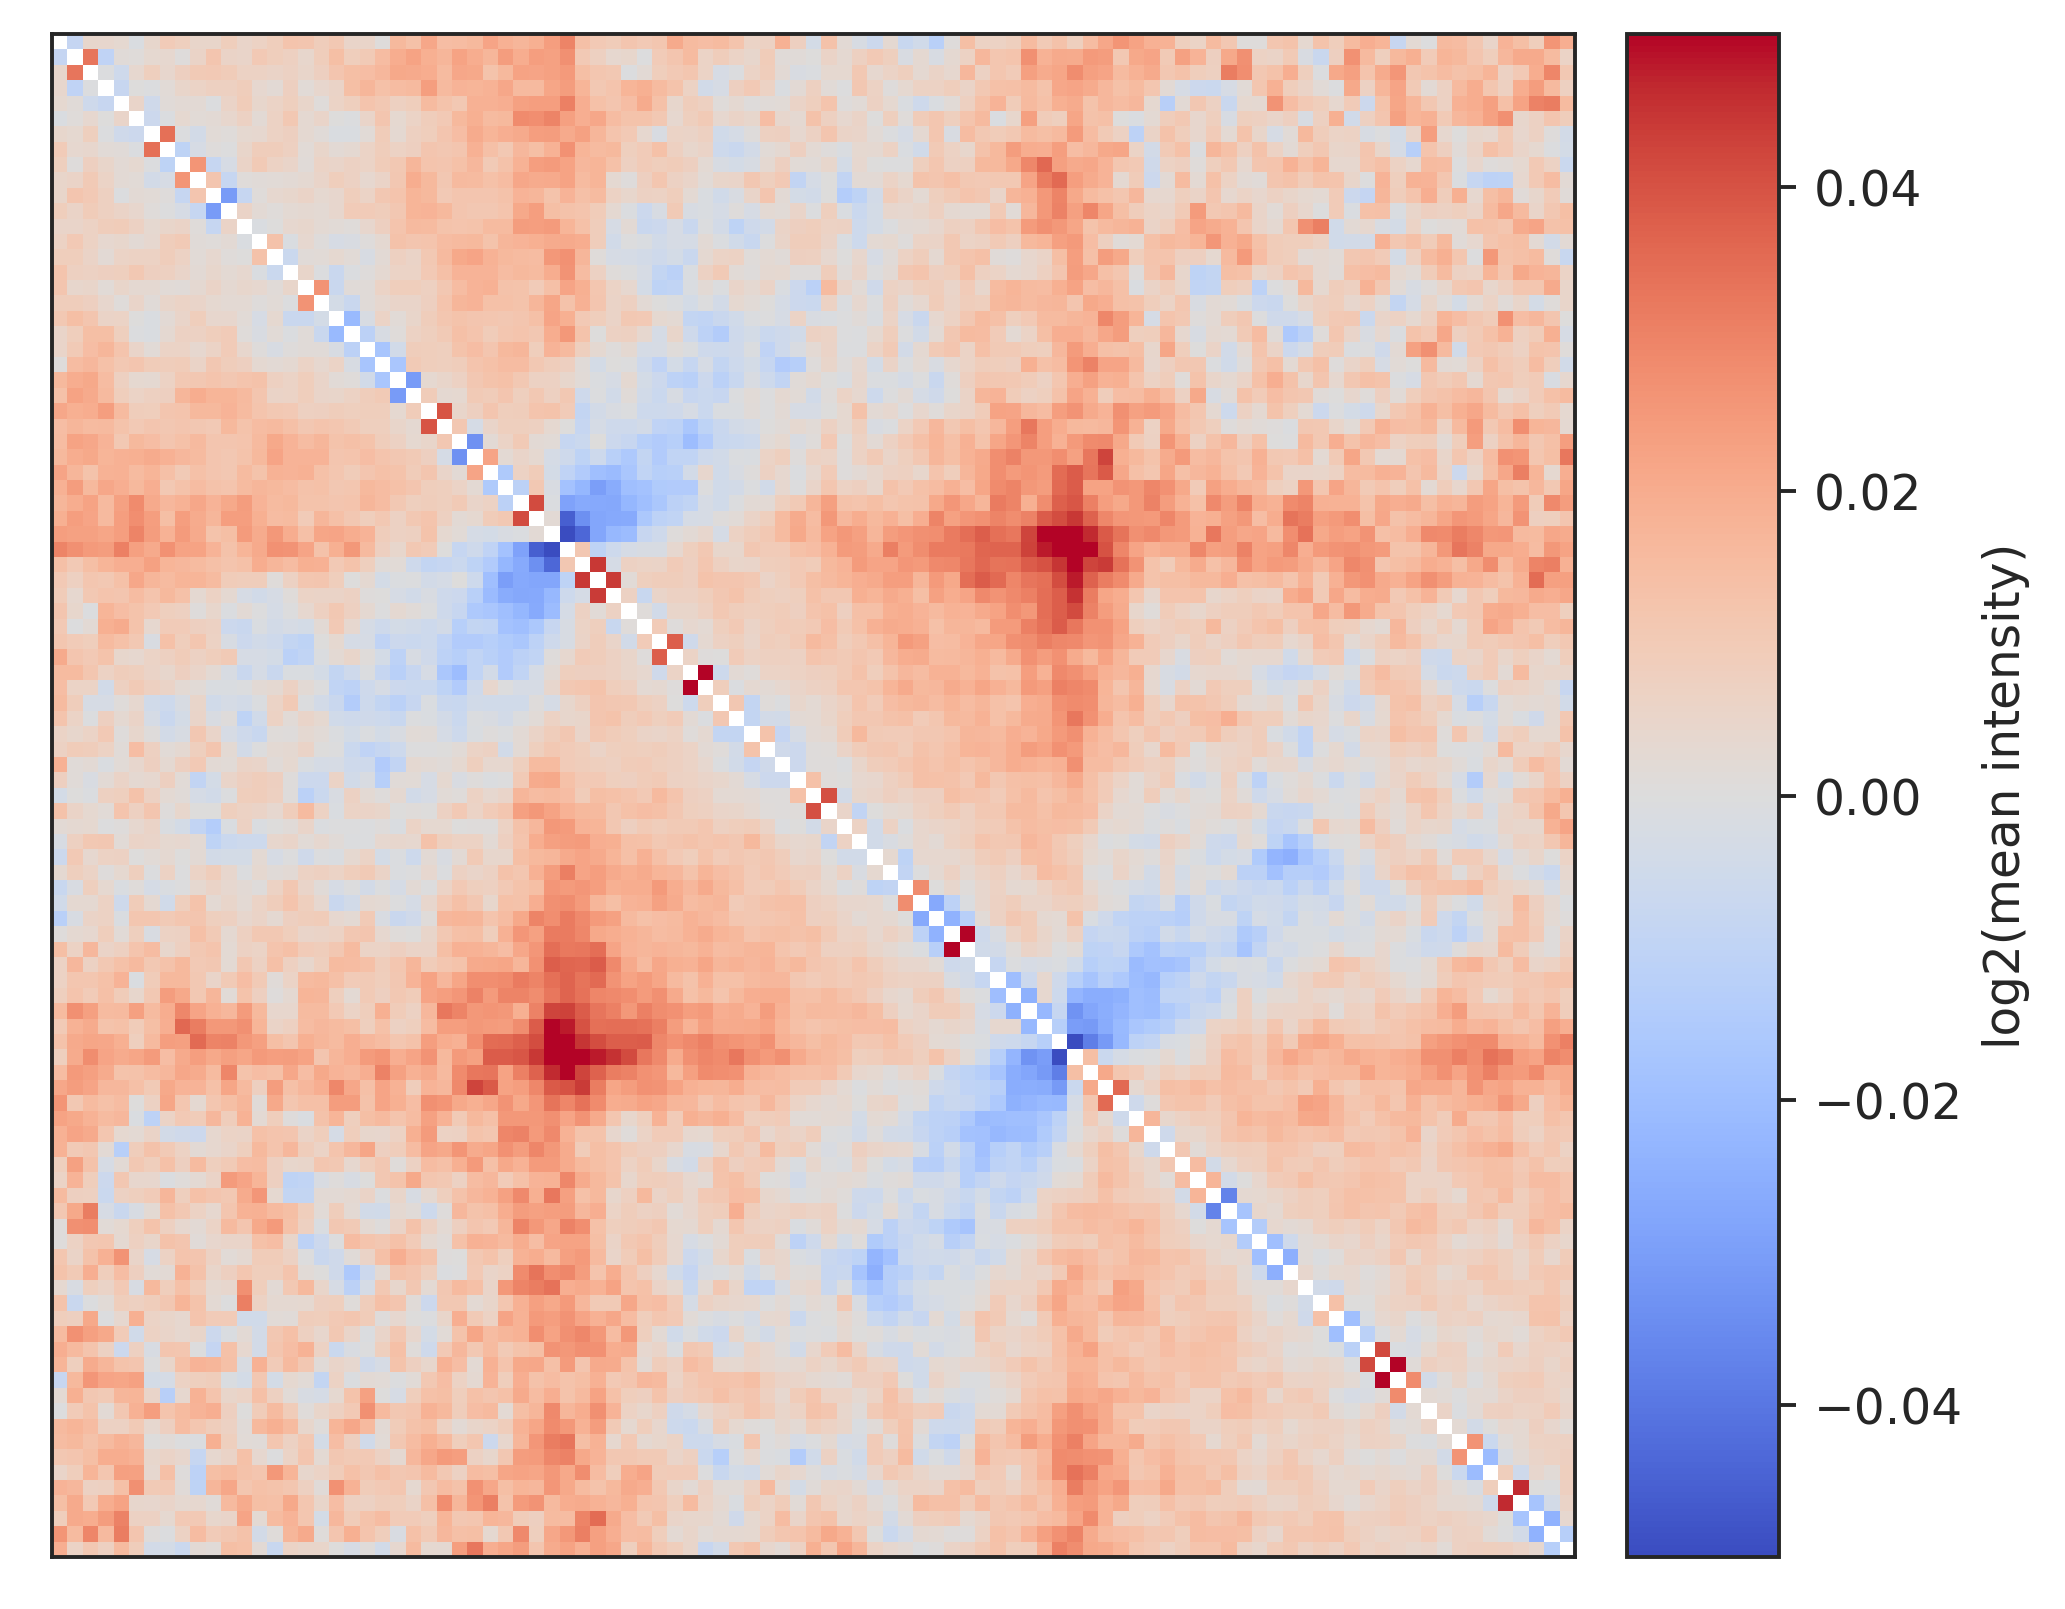

In [31]:
visualize_ratio(av_tad_old, vmin=-0.055, vmax=0.055)

#### S6-KO/Adult pileup

In [32]:
tad_file = merged_ko.drop(columns=['ins_score']) 

tad_file.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_ko, expected_adl]

av_tad_ko = create_average_tad_borders(tad_file, ko_clr, wt_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr9_p', 'chr9_p'): 561
INFO:coolpuppy:('chr8_p', 'chr8_p'): 512
INFO:coolpuppy:('chr10_p', 'chr10_p'): 535
INFO:coolpuppy:('chr6_p', 'chr6_p'): 663
INFO:coolpuppy:('chr4_p', 'chr4_p'): 686
INFO:coolpuppy:('chr7_p', 'chr7_p'): 661
INFO:coolpuppy:('chr5_p', 'chr5_p'): 670
INFO:coolpuppy:('chr3_p', 'chr3_p'): 654
INFO:coolpuppy:('chr2_p', 'chr2_p'): 763
INFO:coolpuppy:('chr1_p', 'chr1_p'): 816
INFO:coolpuppy:('chr16_p', 'chr16_p'): 416
INFO:coolpuppy:('chr19_p', 'chr19_p'): 254
INFO:coolpuppy:('chr11_p', 'chr11_p'): 548
INFO:coolpuppy:('chr15_p', 'chr15_p'): 446
INFO:coolpuppy:('chr13_p', 'chr13_p'): 511
INFO:coolpuppy:('chr12_p', 'chr12_p'): 470
INFO:coolpuppy:('chr14_p', 'chr14_p'): 445
INFO:coolpuppy:('chr18_p', 'chr18_p'): 380
INFO:coolpuppy:('chr17_p', 'chr17_p'): 410
INFO:coolpuppy:('chrX_p', 'chrX_p'): 664
INFO:coolpuppy:Total number of piled up windows: 11065
INFO:coolpuppy:Rescaling with rescale_fla

/tmp/ipykernel_3251894/4136544970.py:90: RuntimeWarning: invalid value encountered in divide
  ratio = stacks[0] / stacks[1]


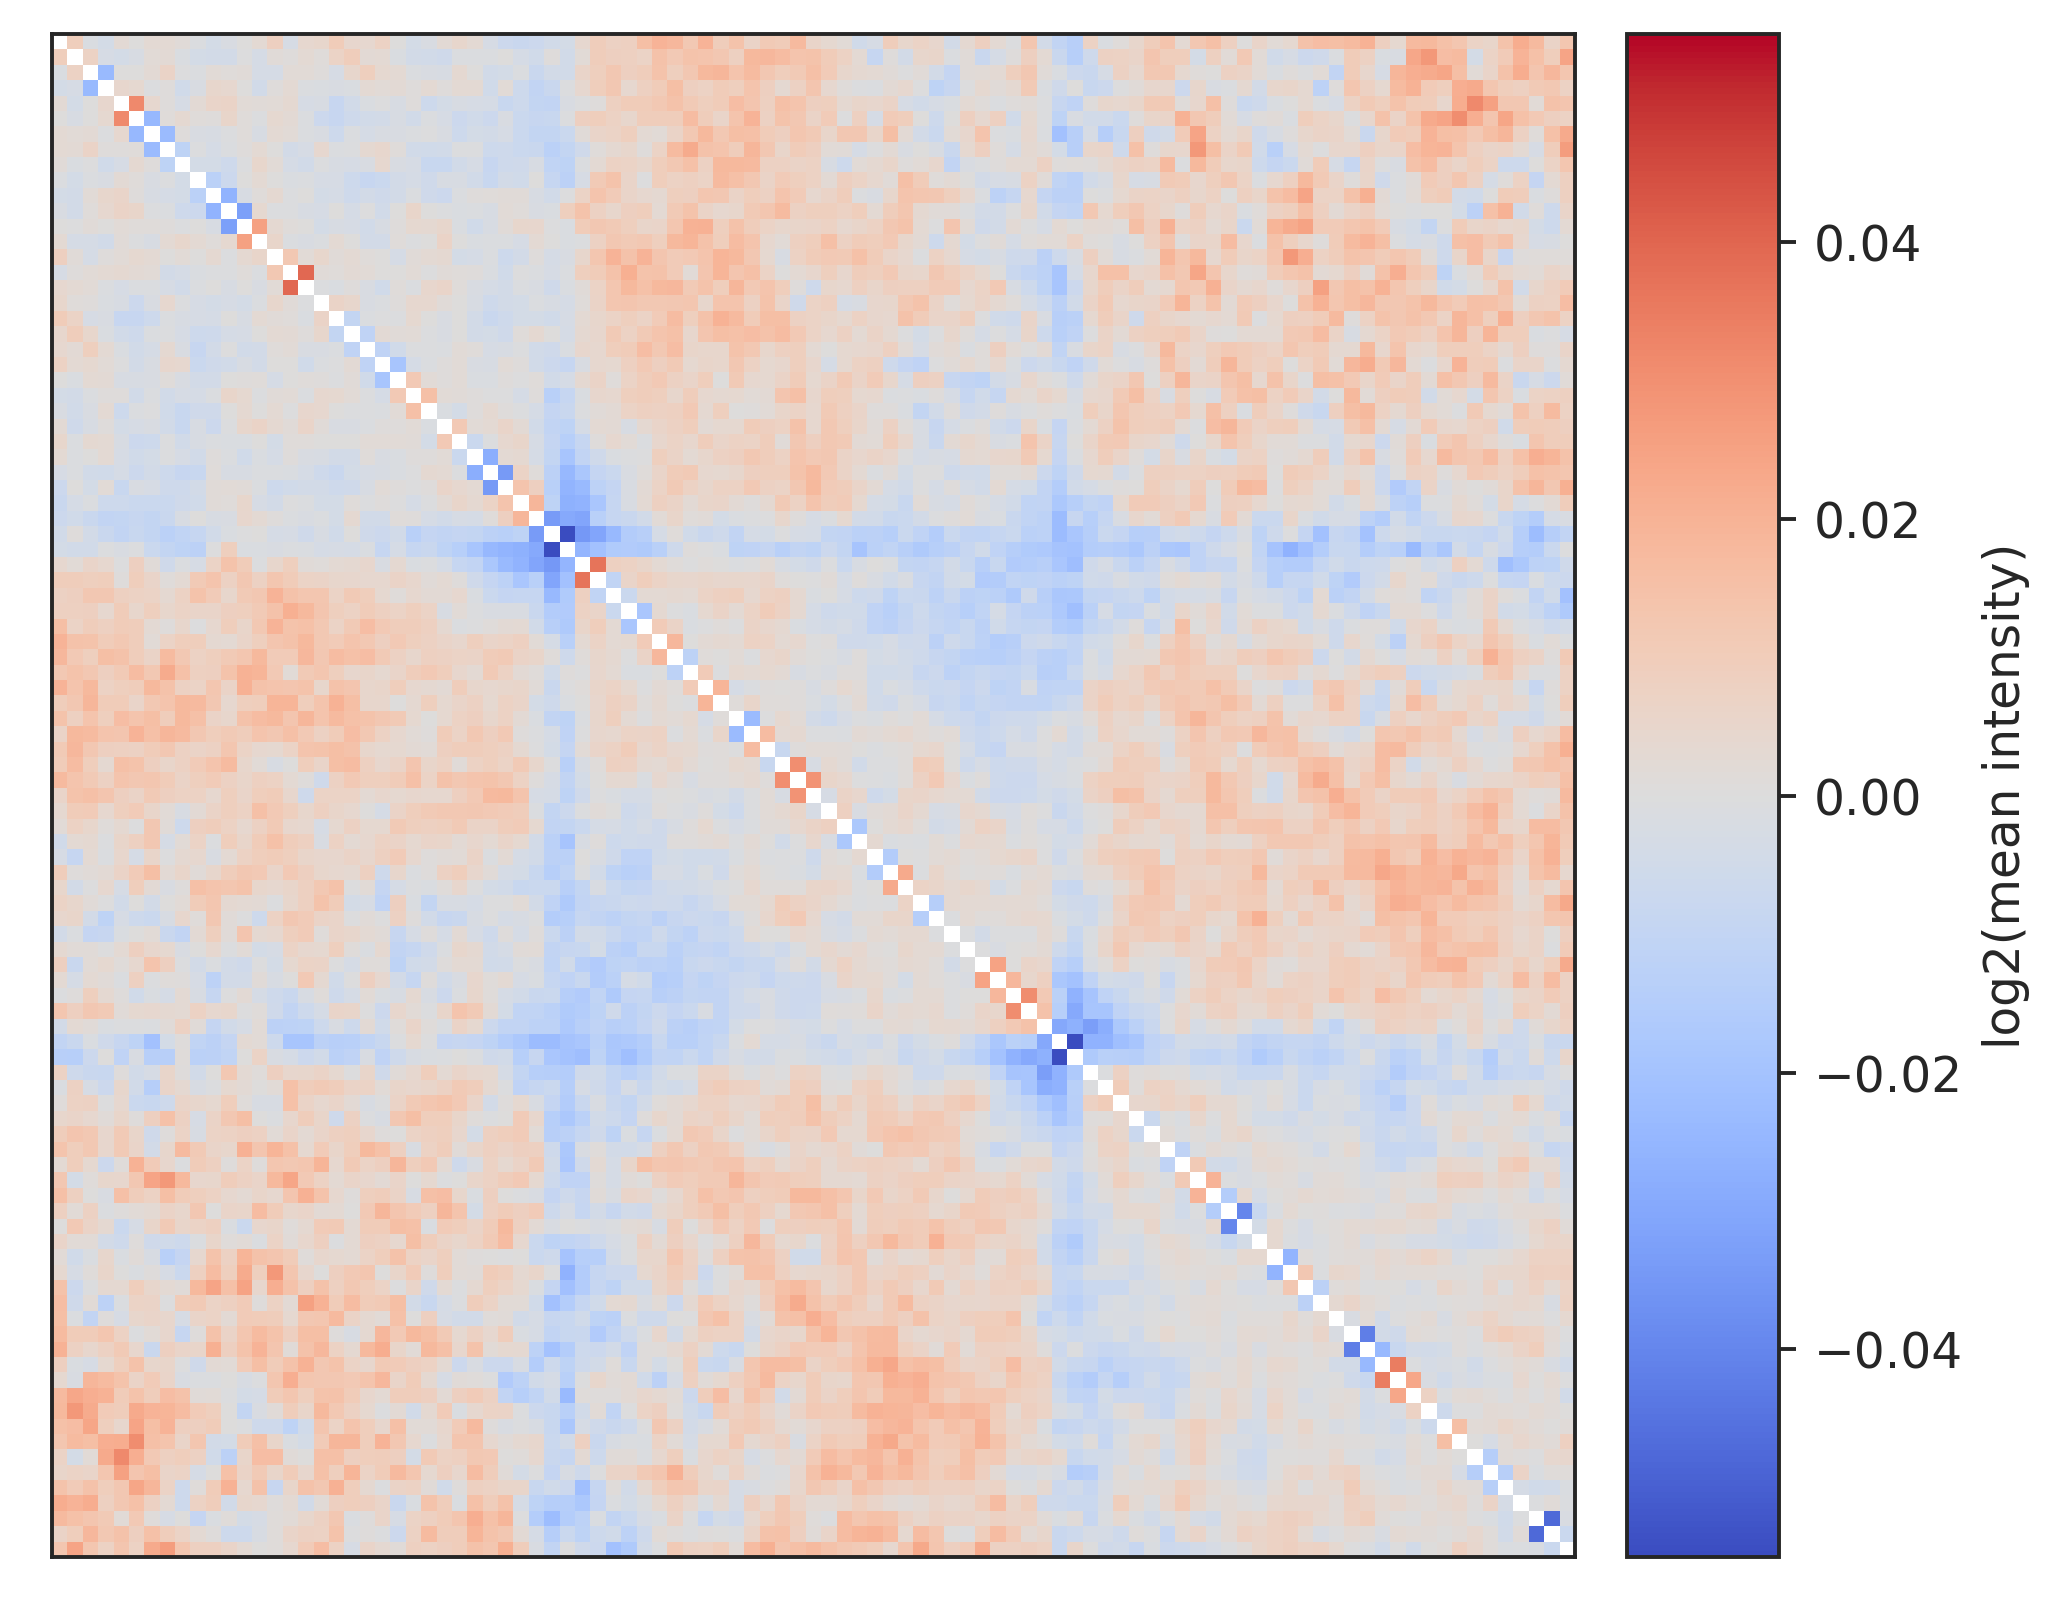

In [33]:
visualize_ratio(av_tad_ko, vmin=-0.055, vmax=0.055)

### Log2​ ratios of contact intensities, computed from the center of the bottom to the top of the central average TAD triangle in S6-KO/adult WT and Old/adult WT comparisons

In [34]:
def compute_log_ratio(treatment_data, control_data):
    """ Computes the log2-transformed ratio of treatment over control. """
    ratio = np.divide(treatment_data, control_data, out=np.zeros_like(treatment_data), where=control_data != 0)
    ratio[ratio == np.inf] = np.nan  
    log_ratio = np.log2(ratio)  
    return log_ratio

def extract_scaling_values(log_ratio, start=(50, 50), end=(66, 33)):
    """
    Extracts values along a diagonal path or custom path for scaling.
    Args:
        log_ratio: The matrix of log-transformed ratios.
        start: Starting coordinate for the path (Ox).
        end: Ending coordinate for the path (Oy).
    Returns:
        distances: Distances from the start along the path.
        values: Log-ratio values along the path.
    """
    x, y = start
    end_x, end_y = end
    values = []
    distances = []

    distance = 0
    while x <= end_x and y >= end_y:
        if log_ratio[x, y] != np.nan:
            values.append(log_ratio[x, y])
            distances.append(distance)
        x += 1  
        y -= 1 
        distance += 1
    
    return distances, values

In [35]:
log_ratio_old_adl = compute_log_ratio(av_tad_old[0], av_tad_old[1])
log_ratio_ko_adl = compute_log_ratio(av_tad_ko[0], av_tad_ko[1])

distances_ko, scaling_values_ko = extract_scaling_values(log_ratio_ko_adl)
distances_old, scaling_values_old = extract_scaling_values(log_ratio_old_adl)


/tmp/ipykernel_3251894/3359541022.py:5: RuntimeWarning: divide by zero encountered in log2
  log_ratio = np.log2(ratio)  # Use log2 for ratio transformation


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


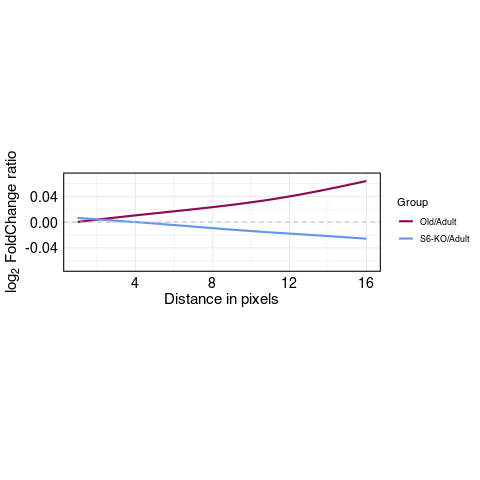

In [36]:
%%R

library(reticulate)
library(splines)
library(ggplot2)

remove_nan_inf <- function(distances, values) {
  valid_indices <- !is.na(values) & is.finite(values)
  return(list(distances[valid_indices], values[valid_indices]))
}

prepare_smooth_data <- function(distances, values, label) {
  filtered_data <- remove_nan_inf(distances, values)
  distances <- filtered_data[[1]]
  values <- filtered_data[[2]]
  

  sorted_indices <- order(distances)
  distances <- distances[sorted_indices]
  values <- values[sorted_indices]
  
  unique_data <- unique(data.frame(Distance = distances, Log2_Ratio = values))
  
  # Interpolation
  smooth_distances <- seq(min(unique_data$Distance), max(unique_data$Distance), length.out = 300)
  smooth_values <- predict(smooth.spline(unique_data$Distance, unique_data$Log2_Ratio, spar = 0.7), smooth_distances)$y
  
  return(data.frame(Distance = smooth_distances, Log2_Ratio = smooth_values, Group = label))
}


distances          <- as.numeric( unlist(py_eval('distances_ko')) )
scaling_values_ko  <- as.numeric( unlist(py_eval('scaling_values_ko')) )
scaling_values_old <- as.numeric( unlist(py_eval('scaling_values_old')) )

df_ko <- prepare_smooth_data(distances, scaling_values_ko, "S6-KO/Adult")
df_old <- prepare_smooth_data(distances, scaling_values_old, "Old/Adult")

df <- rbind(df_ko, df_old)

ggplot(df, aes(x = Distance, y = Log2_Ratio, color = Group)) +
  geom_line(size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray") +
  xlab('Distance in pixels') + ylab(expression(log[2]~FoldChange~ratio)) +
  ylim(-0.07, 0.07) +
  theme_minimal() +
  scale_color_manual(values=c('deeppink4', 'cornflowerblue')) +
  theme(
    axis.text = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    #legend.position = "none",
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    aspect.ratio = 1/3.2
  )

### Ratio of intensities from HiCExplorer

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


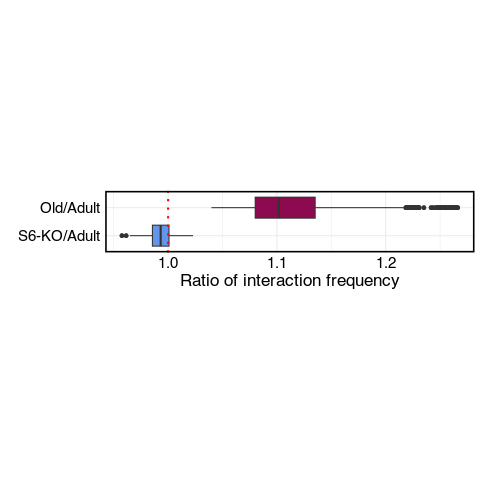

In [37]:
%%R
library(tidyverse)
library(reticulate)

np <- import("numpy")

npz_old <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_center.npz')
npz_ko <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_center.npz')
npz_adl <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_TADs_center.npz')


data_old <- npz_old$f[["data"]]
data_ko <- npz_ko$f[["data"]]
data_adl <- npz_adl$f[["data"]]

ko_adl <- data_ko/data_adl
old_adl <- data_old/data_adl

df <- data.frame(value = c(ko_adl, old_adl))
ko_adl_v <- rep(paste0('S6-KO/Adult'), times=length(ko_adl))
old_adl_v <- rep(paste0('Old/Adult'), times=length(old_adl))

df$type <- c(ko_adl_v, old_adl_v)
df$type <- factor(df$type, levels=c('S6-KO/Adult', 'Old/Adult'))


m = ggplot(df, aes(x = value, y = type)) +
  geom_boxplot(aes(fill = type), show.legend = FALSE) +
  ylab('') +
  xlab('Ratio of interaction frequency') +
  #xlim(0.6, 1.5) +
  theme_minimal() +
  geom_vline(xintercept=1, linetype='dotted', col = 'red', size=1) +
  theme(axis.text.x=element_text(color = "black",size = 15),
        axis.title.x = element_text(size = 17, colour='black'),
        axis.text.y = element_text(size = 15, colour='black'),
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1/6) +
  scale_fill_manual(values=c('cornflowerblue', 'deeppink4'))

print(m)

#ggsave("/tank/projects/kashuk_sirt6_hic/avTAD/ratio_old_adl_KO_adl.png", m, dpi = 1200)


(`stat_boxplot()`). 



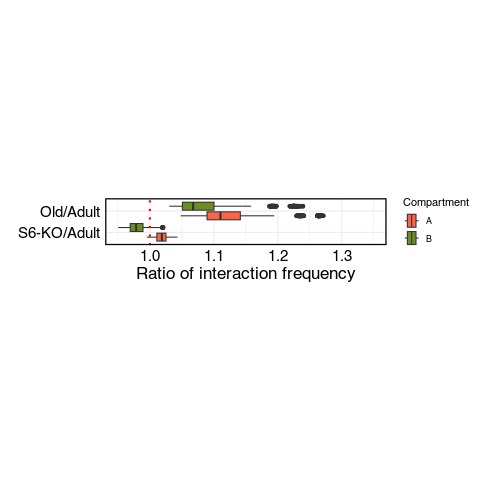

In [38]:
%%R
library(tidyverse)
library(reticulate)

np <- import("numpy")

npz_old_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_comp_A_center.npz')
npz_old_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_comp_B_center.npz')
npz_ko_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_comp_A_center.npz')
npz_ko_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_comp_B_center.npz')
npz_adl_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_TADs_comp_A_center.npz')
npz_adl_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_TADs_comp_B_center.npz')


data_old_a <- npz_old_a$f[["data"]]
data_old_b <- npz_old_b$f[["data"]]
data_ko_a <- npz_ko_a$f[["data"]]
data_ko_b <- npz_ko_b$f[["data"]]
data_adl_a <- npz_adl_a$f[["data"]]
data_adl_b <- npz_adl_b$f[["data"]]

ko_adl_a <- data_ko_a/data_adl_a
ko_adl_b <- data_ko_b/data_adl_b
old_adl_a <- data_old_a/data_adl_a
old_adl_b <- data_old_b/data_adl_b


df <- data.frame(
  value = c(ko_adl_a, ko_adl_b, old_adl_a, old_adl_b),
  type = c(
    rep('S6-KO/Adult', length(ko_adl_a)),
    rep('S6-KO/Adult', length(ko_adl_b)),
    rep('Old/Adult',   length(old_adl_a)),
    rep('Old/Adult',   length(old_adl_b))
  ),
  compartment = c(
    rep('A', length(ko_adl_a)),
    rep('B', length(ko_adl_b)),
    rep('A', length(old_adl_a)),
    rep('B', length(old_adl_b))
  )
)

df$type <- factor(df$type, levels=c('S6-KO/Adult','Old/Adult'))
df$compartment <- factor(df$compartment, levels=c('A','B'))

m = ggplot(df, aes(x = value, y = type, fill = compartment)) +
  geom_boxplot(position = position_dodge(width = 0.9)) + 
  xlim(0.95, 1.35) +
  ylab('') +
  xlab('Ratio of interaction frequency') +
  geom_vline(xintercept=1, linetype='dotted', col='red', size=1) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color="black", size=15),
    axis.title.x = element_text(size=17, colour='black'),
    axis.text.y = element_text(size=15, colour='black'),
    panel.border = element_rect(colour="black", fill=NA, size=1.2),
    aspect.ratio = 1/6
  ) +
  scale_fill_manual(values=c('tomato1','olivedrab'),
                    name = "Compartment")

m

#ggsave('Ratio_interaction_frequency_A_B_comp_old_KO.pdf', m, dpi=1200)

In [39]:
%%R

library(dplyr)

pvals <- df %>%
  group_by(type, compartment) %>%
  summarise(
    p_value = wilcox.test(value, mu = 1)$p.value,
    median_val = median(value),
    .groups = 'drop'
  )

print(pvals)

# A tibble: 4 × 4
  type        compartment   p_value median_val
  <fct>       <fct>           <dbl>      <dbl>
1 S6-KO/Adult A           7.22e-246      1.02 
2 S6-KO/Adult B           2.07e-210      0.978
3 Old/Adult   A           1.68e-256      1.11 
4 Old/Adult   B           1.68e-256      1.07 


In [40]:
%%R

library(dplyr)

# ── Wilcoxon-test: S6-KO/Adult vs Old/Adult  ────
results <- df %>%
  group_by(compartment) %>%
  summarise(
    p_value  = wilcox.test(value[type == 'S6-KO/Adult'],
                           value[type == 'Old/Adult'])$p.value,
    median_KO  = median(value[type == 'S6-KO/Adult'], na.rm = TRUE),
    median_Old = median(value[type == 'Old/Adult'],   na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    comparison   = paste0('S6-KO vs Old | compartment ', compartment),
    p_adj        = p.adjust(p_value, method = 'BH'),
    significance = case_when(
      p_adj < 0.001 ~ '***',
      p_adj < 0.01  ~ '**',
      p_adj < 0.05  ~ '*',
      TRUE          ~ 'ns'
    )
  )

print(results)

# A tibble: 2 × 7
  compartment p_value median_KO median_Old comparison         p_adj significance
  <fct>         <dbl>     <dbl>      <dbl> <chr>              <dbl> <chr>       
1 A                 0     1.02        1.11 S6-KO vs Old | co…     0 ***         
2 B                 0     0.978       1.07 S6-KO vs Old | co…     0 ***         


## Inclusion rate

In [12]:
import cooler
import numpy as np
import pandas as pd
from tqdm import tqdm


def compute_inclusion_ratio(clr, chrom, tad_start, tad_end, resolution):
    """
    Compute the HOMER-style inclusion ratio (IR) for a single TAD.

    IR = intra-TAD interactions / (TAD-to-flank interactions)
    Flanks are the same size as the TAD, upstream and downstream.
    The denominator is inter-TAD only, so IR is unbounded above
    (dense, well-insulated TADs give IR >> 1), as defined by HOMER.
    """
    tad_size = tad_end - tad_start

    flank_start = max(0, tad_start - tad_size)
    flank_end = min(clr.chromsizes[chrom], tad_end + tad_size)

    try:
        matrix = clr.matrix(balance=True).fetch(
            f"{chrom}:{flank_start}-{flank_end}"
        )
    except Exception:
        return np.nan

    region_start = flank_start
    tad_bin_start = (tad_start - region_start) // resolution
    tad_bin_end = (tad_end - region_start) // resolution

    n = matrix.shape[0]
    tad_bin_end = min(tad_bin_end, n)

    if tad_bin_start >= tad_bin_end:
        return np.nan

    # Intra-TAD interactions
    intra = matrix[tad_bin_start:tad_bin_end, tad_bin_start:tad_bin_end]
    intra_sum = np.nansum(intra)

    # Inter-TAD: TAD vs upstream flank
    upstream = matrix[:tad_bin_start, tad_bin_start:tad_bin_end]
    upstream_sum = np.nansum(upstream)

    # Inter-TAD: TAD vs downstream flank
    downstream = matrix[tad_bin_end:, tad_bin_start:tad_bin_end]
    downstream_sum = np.nansum(downstream)

    inter_sum = upstream_sum + downstream_sum

    # HOMER: IR = intra / inter 
    if inter_sum == 0:
        return np.nan  

    ir = intra_sum / inter_sum
    return ir


def score_tads(cool_file, tad_bed, resolution=10000):
    """
    Score TADs from a BED-like DataFrame using a cooler object.
    """
    clr = cool_file
    tads = tad_bed.copy()

    results = []
    for _, row in tqdm(tads.iterrows(), total=len(tads)):
        chrom, start, end = row["chr"], row["start"], row["end"]

        if chrom not in clr.chromsizes:
            results.append(np.nan)
            continue

        ir = compute_inclusion_ratio(clr, chrom, start, end, resolution)
        results.append(ir)

    tads["inclusion_ratio"] = results
    return tads


df_adl = score_tads(
    cool_file=wt_clr,
    tad_bed=merged_adl,
    resolution=10000,
)

df_old = score_tads(
    cool_file=old_clr,
    tad_bed=merged_old,
    resolution=10000,
)

df_ko = score_tads(
    cool_file=ko_clr,
    tad_bed=merged_ko,
    resolution=10000,
)

df_adl.to_csv("tad_inclusion_ratios_adult.csv", index=False)
df_old.to_csv("tad_inclusion_ratios_old.csv", index=False)
df_KO.to_csv("tad_inclusion_ratios_KO.csv", index=False)
print(df_adl.head())

100%|██████████| 11502/11502 [03:31<00:00, 54.50it/s]

    chr    start      end  ins_score  inclusion_ratio
0  chr1  3150000  3669999  -0.740220         2.330364
1  chr1  3670000  4069999  -0.503155         1.759406
2  chr1  4070000  4569999  -0.972498         1.663865
3  chr1  4570000  4759999  -0.714962         1.820128
4  chr1  4760000  5089999  -0.456965         2.652371


Rows: 11502 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chr
dbl (4): start, end, ins_score, inclusion_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 10790 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chr
dbl (4): start, end, ins_score, inclusion_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 11067 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chr
dbl (4): start, end, ins_score, inclusion_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this mess

In addition: Warning messages:
1: Removed 240 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
2: Removed 240 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


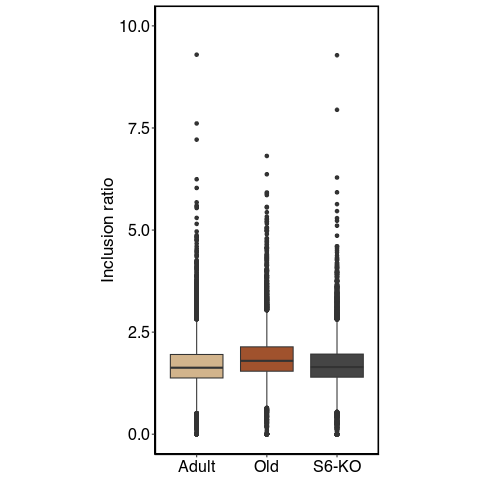

In [45]:
%%R

library(tidyverse)

samples <- list(
  Adult = "tad_inclusion_ratios_adult.csv",
  Old   = "tad_inclusion_ratios_old.csv",
  'S6-KO'    = "tad_inclusion_ratios_KO.csv"
)

combined <- map_dfr(samples, read_csv, .id = "sample") %>%
  mutate(sample = factor(sample, levels = c("Adult", "Old", "S6-KO")))

p <- ggplot(combined, aes(x = sample, y = inclusion_ratio, fill=sample)) +
  geom_boxplot() +
  theme_classic() +
  ylim(0,10) +
  labs(
    x = NULL,
    y = "Inclusion ratio"
  ) + 
  scale_fill_manual(values=c('tan', 'sienna', 'gray27')) +
  theme(axis.text.x = element_text(size = 16, colour = 'black'),
        axis.text.y = element_text(size = 16, colour = 'black'),
        axis.title.y = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.position = 'none',
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 2/1)

print(p)

#ggsave("tad_inclusion_ratios_HOMER.pdf", dpi=1200, width = 4, height = 5)

In [46]:
%%R

adult <- combined %>% filter(sample == "Adult") %>% pull(inclusion_ratio)
old   <- combined %>% filter(sample == "Old")   %>% pull(inclusion_ratio)
ko    <- combined %>% filter(sample == "S6-KO")    %>% pull(inclusion_ratio)

print(wilcox.test(adult, old))
print(wilcox.test(adult, ko))


	Wilcoxon rank sum test with continuity correction

data:  adult and old
W = 47980711, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  adult and ko
W = 61526158, p-value = 0.01657
alternative hypothesis: true location shift is not equal to 0



In [30]:
#### One-sample Wilcoxon signed-rank test for Old/Adult vs S6-KO/Adult

In [11]:
%%R


wilcox_test_ko <- wilcox.test(ko_adl, mu = 1)
wilcox_test_old <- wilcox.test(old_adl, mu = 1)


print("S6-KO/Adult vs 1:")
print(wilcox_test_ko)
print("Old/Adult vs 1:")
print(wilcox_test_old)

[1] "S6-KO/Adult vs 1:"

	Wilcoxon signed rank test with continuity correction

data:  ko_adl
V = 233131, p-value < 2.2e-16
alternative hypothesis: true location is not equal to 1

[1] "Old/Adult vs 1:"

	Wilcoxon signed rank test with continuity correction

data:  old_adl
V = 1217580, p-value < 2.2e-16
alternative hypothesis: true location is not equal to 1



### Ratio of boundary strength

#### Common boundaries

In [47]:
import pandas as pd

def pair_boundaries(df1: pd.DataFrame,
                    df2: pd.DataFrame,
                    tol: int = 10_000) -> pd.DataFrame:
    """
    For each boundary in df1, finds the closest boundary in df2 on the same chromosome
    within +/- tol base‐pairs. Returns a DataFrame of matched pairs.
    
    Expects that df1 and df2 have at least these columns (in any case):
      - 'chrom'
      - 'start'
      - 'end'
    """
    df1 = df1.copy()
    df2 = df2.copy()
    
    for df in (df1, df2):
        if 'Chr' in df.columns:
            df.rename(columns={'Chr':'chr'}, inplace=True)
        elif 'chrom' in df.columns:
            df.rename(columns={'chrom':'chr'}, inplace=True)
        df.columns = [c.lower() for c in df.columns]
    
    for col in ('chr','start','end'):
        if col not in df1.columns or col not in df2.columns:
            raise KeyError(f"Missing required column '{col}' in one of the inputs")
    
    df1[['start','end']] = df1[['start','end']].astype(int)
    df2[['start','end']] = df2[['start','end']].astype(int)
    
    df2_index = {chrom: sub for chrom, sub in df2.groupby('chr')}
    
    matches = []
    for _, row1 in df1.iterrows():
        chrom = row1['chr']
        if chrom not in df2_index:
            continue
        cand = df2_index[chrom]
        dists = (cand['start'] - row1['start']).abs()
        min_dist = dists.min()
        if min_dist <= tol:
            best_idx = dists.idxmin()
            row2 = cand.loc[best_idx]
            matches.append({
                'chr1':     chrom,
                'start1':   row1['start'],
                'end1':     row1['end'],
                'chr2':     row2['chr'],
                'start2':   row2['start'],
                'end2':     row2['end'],
                'distance': int(min_dist)
            })
    
    return pd.DataFrame(matches,
                        columns=['chr1','start1','end1',
                                 'chr2','start2','end2'])


In [48]:
df_adl_old = pair_boundaries(merged_adl, merged_old)
df_adl_ko  = pair_boundaries(merged_adl, merged_ko)

In [49]:
df_adl_old

,chr1,start1,end1,chr2,start2,end2
0,chr1,3150000,3669999,chr1,3150000,3679999
1,chr1,3670000,4069999,chr1,3680000,4119999
2,chr1,4570000,4759999,chr1,4570000,4759999
3,chr1,4760000,5089999,chr1,4760000,5089999
4,chr1,5090000,5189999,chr1,5090000,5179999
...,...,...,...,...,...,...
7622,chrX,166650000,166809999,chrX,166650000,167259999
7623,chrX,167500000,168119999,chrX,167490000,167829999
7624,chrX,168120000,168679999,chrX,168130000,168679999
7625,chrX,168680000,168939999,chrX,168680000,168939999


In [50]:
### TAD boundaries strength:

start, end = 1_000_000, 300_000_000
chromosomes = [f"chr{i}" for i in range(1,20)] + ["chrX","chrY"]

def get_merged_boundaries(insulation_table, window=50000):
    """
    Given a bioframe-style insulation_table DataFrame,
    returns a DataFrame of all (chrom, start, end, strength) boundary pairs.
    """
    merged = []
    bs_col   = f"boundary_strength_{window}"
    flag_col = f"is_boundary_{window}"
    
    for chrom in chromosomes:
        # select the region of interest
        region     = (chrom, start, end)
        ins_region = bioframe.select(insulation_table, region)
        
        # keep only non-NaN strengths and flagged boundaries
        keep = ins_region[~np.isnan(ins_region[bs_col])]
        keep = keep[ keep[flag_col] ]
        
        if keep.shape[0] < 2:
            continue
        
        starts    = keep["start"].to_numpy(dtype=int)
        ends      = keep["end"].to_numpy(dtype=int)
        strengths = keep[bs_col].to_numpy(dtype=float)
        
        # replace every even-positioned start with its corresponding end
        evens = np.arange(1, len(starts), 2)
        starts[evens] = ends[evens]

        df_chr = pd.DataFrame({
            "chr":      chrom,
            "start":    starts[:-1],
            "end":      starts[1:] - 1,
            "strength": strengths[:-1]
        })
        merged.append(df_chr)
    
    # concatenate all chromosomes
    if merged:
        return pd.concat(merged, ignore_index=True)
    else:
        return pd.DataFrame(columns=["chr","start","end","strength"])

In [51]:
merged_adl = get_merged_boundaries(adl_insulation)
merged_old = get_merged_boundaries(old_insulation)
merged_ko  = get_merged_boundaries(ko_insulation)

In [52]:
merged_adl

,chr,start,end,strength
0,chr1,3150000,3669999,1.138739
1,chr1,3670000,4069999,0.751138
2,chr1,4070000,4569999,1.312775
3,chr1,4570000,4759999,1.036296
4,chr1,4760000,5089999,0.727079
...,...,...,...,...
11497,chrX,167500000,168119999,0.868207
11498,chrX,168120000,168679999,0.610859
11499,chrX,168680000,168939999,0.716298
11500,chrX,168940000,169329999,0.408947



(`stat_boxplot()`). 



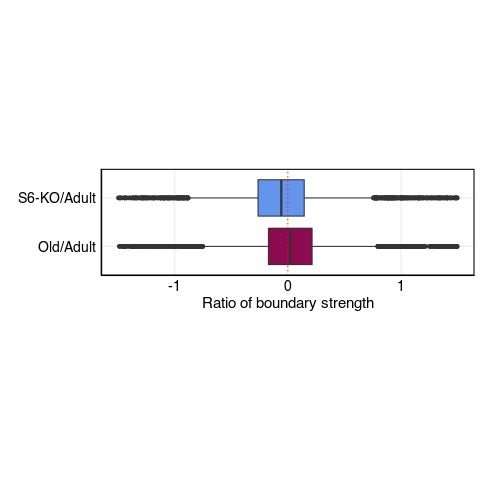

In [60]:
%%R

df_adl_old <- py_eval('df_adl_old')
df_adl_ko <- py_eval('df_adl_ko')

merged_adl <- py_eval('merged_adl')
merged_old <- py_eval('merged_old')
merged_ko <- py_eval('merged_ko')

adl_old <- merge(df_adl_old, merged_adl, by.x = c('chr1', 'start1', 'end1'), by.y = c('chr', 'start', 'end'))
adl_old2 <- merge(adl_old, merged_old, by.x = c('chr2', 'start2', 'end2'), by.y = c('chr', 'start', 'end'))
adl_old2$ratio <- adl_old2$strength.y / adl_old2$strength.x

adl_ko <- merge(df_adl_ko, merged_adl, by.x = c('chr1', 'start1', 'end1'), by.y = c('chr', 'start', 'end'))
adl_ko2 <- merge(adl_ko, merged_ko, by.x = c('chr2', 'start2', 'end2'), by.y = c('chr', 'start', 'end'))
adl_ko2$ratio <- adl_ko2$strength.y / adl_ko2$strength.x

ratio <- c(log2(adl_old2$ratio), log2(adl_ko2$ratio))
type <- c(rep('Old/Adult', length(adl_old2$ratio)), rep('S6-KO/Adult', length(adl_ko2$ratio)))

df <- data.frame(ratio, type)
df$type <- factor(df$type, levels=c('Old/Adult', 'S6-KO/Adult'))

ggplot(df, aes(ratio, type, fill=type)) +
  geom_boxplot() +
  xlim(-1.5, 1.5) +
  geom_vline(xintercept=0, linetype="dotted", color='red') + 
  xlab('Ratio of boundary strength') + ylab('') +
  theme_minimal() +
  theme(axis.text.y   = element_text(size=14, color='black'),
        axis.text.x   = element_text(size=14, color='black'),
        axis.title.x  = element_text(size=15, color='black'),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        aspect.ratio = 2/7,
        legend.position = 'none'
  ) +
  scale_fill_manual(values=c('deeppink4', 'cornflowerblue', 'cyan', 'grey'))

In [54]:
#### One-sample Wilcoxon signed-rank test for Old/Adult vs S6-KO/Adult

In [61]:
%%R

ratio_old <- log2(adl_old2$ratio)
ratio_ko <- log2(adl_ko2$ratio)

wilcox_test_old <- wilcox.test(ratio_old, mu = 0)
wilcox_test_ko <- wilcox.test(ratio_ko, mu = 0)

print("Old/Adult (log2 ratio) vs 0:")
print(wilcox_test_old)
print("S6-KO/Adult (log2 ratio) vs 0:")
print(wilcox_test_ko)

[1] "Old/Adult (log2 ratio) vs 0:"

	Wilcoxon signed rank test with continuity correction

data:  ratio_old
V = 15523780, p-value = 3.554e-07
alternative hypothesis: true location is not equal to 0

[1] "S6-KO/Adult (log2 ratio) vs 0:"

	Wilcoxon signed rank test with continuity correction

data:  ratio_ko
V = 14115992, p-value < 2.2e-16
alternative hypothesis: true location is not equal to 0



### Differential TAD boundaries

#### Function to identify differential TAD boundaries

In [62]:
import pandas as pd

def remove_duplicates(df1: pd.DataFrame,
                      df2: pd.DataFrame,
                      tol: int = 10_000) -> (pd.DataFrame, pd.DataFrame):
    """
    From df1 and df2, remove any row in df1 that has a 'duplicate'
    in df2 (same chr, start within tol bp), and vice versa.
    
    Returns (unique_to_df1, unique_to_df2).
    """
    df1 = df1.rename(columns=str.lower)
    df2 = df2.rename(columns=str.lower)
    for df in (df1, df2):
        if 'chr' not in df.columns or 'start' not in df.columns:
            raise KeyError("Both DataFrames must have 'chr' and 'start' columns")
    
    df2_index = {chrom: grp['start'].to_numpy(dtype=int)
                 for chrom, grp in df2.groupby('chr')}
    df1_index = {chrom: grp['start'].to_numpy(dtype=int)
                 for chrom, grp in df1.groupby('chr')}
    
    mask1 = []
    for _, row in df1.iterrows():
        starts2 = df2_index.get(row['chr'], None)
        if starts2 is not None and (abs(starts2 - int(row['start'])) <= tol).any():
            mask1.append(True)
        else:
            mask1.append(False)
    
    mask2 = []
    for _, row in df2.iterrows():
        starts1 = df1_index.get(row['chr'], None)
        if starts1 is not None and (abs(starts1 - int(row['start'])) <= tol).any():
            mask2.append(True)
        else:
            mask2.append(False)
    
    unique1 = df1.loc[~pd.Series(mask1, index=df1.index)].reset_index(drop=True)
    unique2 = df2.loc[~pd.Series(mask2, index=df2.index)].reset_index(drop=True)
    
    return unique1, unique2


In [63]:
unique_old_adl = remove_duplicates(merged_old, merged_adl)[0]
unique_ko_adl = remove_duplicates(merged_ko, merged_adl)[0]

In [64]:
unique_ko_adl

,chr,start,end,strength
0,chr1,4860000,5079999,0.388944
1,chr1,7400000,7479999,0.802805
2,chr1,7940000,8199999,0.656916
3,chr1,10010000,10239999,0.391713
4,chr1,10890000,10969999,1.681110
...,...,...,...,...
2721,chrX,167390000,167499999,0.478313
2722,chrX,167820000,168139999,0.457813
2723,chrX,168140000,168679999,0.548353
2724,chrX,169310000,169799999,0.799791


In [65]:
def build_index(df: pd.DataFrame) -> dict:
    return {chrom: grp['start'].to_numpy(dtype=int)
            for chrom, grp in df.groupby('chr')}

def get_score(df: pd.DataFrame,
              source_df: pd.DataFrame,
              source_index: dict,
              tol: int = 10_000) -> np.ndarray:
    scores     = np.full(len(df), np.nan)
    starts_arr = df['start'].to_numpy(dtype=int)
    chrs_arr   = df['chr'].to_numpy()

    score_lookup = {(row['chr'], int(row['start'])): row['ins_score']
                    for _, row in source_df.iterrows()}

    for i in range(len(df)):
        chrom  = chrs_arr[i]
        starts = source_index.get(chrom, None)
        if starts is None:
            continue
        diffs   = np.abs(starts - starts_arr[i])
        min_idx = diffs.argmin()
        if diffs[min_idx] <= tol:
            matched_start = int(starts[min_idx])
            scores[i] = score_lookup.get((chrom, matched_start), np.nan)
    return scores

In [69]:
import pandas as pd
import numpy as np

def classify_boundaries_from_venn(adult, old, ko, tol=10_000):
    
    adult = adult.rename(columns=str.lower).copy()
    old   = old.rename(columns=str.lower).copy()
    ko    = ko.rename(columns=str.lower).copy()

    adult_u_old, _ = remove_duplicates(adult, old, tol)
    A_only, _      = remove_duplicates(adult_u_old, ko, tol)

    old_u_adult, _ = remove_duplicates(old, adult, tol)
    O_only, _      = remove_duplicates(old_u_adult, ko, tol)

    ko_u_adult, _  = remove_duplicates(ko, adult, tol)
    K_only, _      = remove_duplicates(ko_u_adult, old, tol)

    pairs_ao   = pair_boundaries(adult, old, tol)
    common_ao  = pairs_ao[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})
    AO_notK, _ = remove_duplicates(common_ao, ko, tol)

    pairs_ak   = pair_boundaries(adult, ko, tol)
    common_ak  = pairs_ak[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})
    AK_notO, _ = remove_duplicates(common_ak, old, tol)

    pairs_ok   = pair_boundaries(old, ko, tol)
    common_ok  = pairs_ok[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})
    OK_notA, _ = remove_duplicates(common_ok, adult, tol)

    pairs_aok  = pair_boundaries(common_ao, ko, tol)
    AOK        = pairs_aok[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})


    A_only['boundary_class']  = 'adult_specific'
    O_only['boundary_class']  = 'old_specific'
    K_only['boundary_class']  = 'ko_specific'
    AO_notK['boundary_class'] = 'adult_old'
    AK_notO['boundary_class'] = 'adult_ko'
    OK_notA['boundary_class'] = 'old_ko'
    AOK['boundary_class']     = 'shared'

    all_bounds = pd.concat(
        [A_only, O_only, K_only, AO_notK, AK_notO, OK_notA, AOK],
        ignore_index=True
    )
    
    idx_adl = build_index(adult)
    idx_old = build_index(old)
    idx_ko  = build_index(ko)

    all_bounds['ins_adult'] = get_score(all_bounds, adult, idx_adl, tol)
    all_bounds['ins_old']   = get_score(all_bounds, old,   idx_old, tol)
    all_bounds['ins_ko']    = get_score(all_bounds, ko,    idx_ko,  tol)

    return all_bounds

boundaries = classify_boundaries_from_venn(merged_adl, merged_old, merged_ko)
print(boundaries['boundary_class'].value_counts())

boundary_class
shared            6230
old_specific      2132
adult_ko          2107
adult_specific    1768
ko_specific       1707
adult_old         1397
old_ko            1033
Name: count, dtype: int64


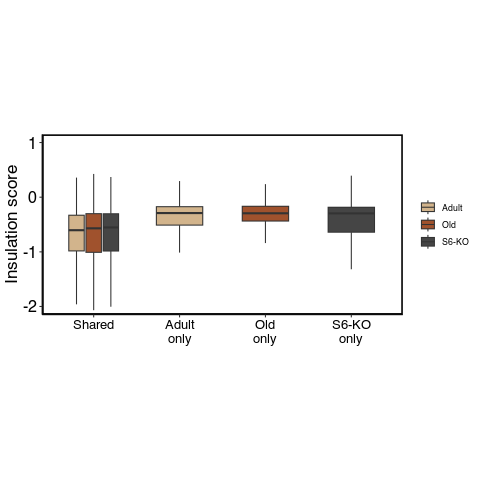

In [70]:
%%R

library(reticulate)
library(dplyr)
library(tidyverse)

b <- py_eval('boundaries')

b_long <- b %>%
  filter(boundary_class %in% c(
    "shared", 
    "adult_specific", "old_specific", "ko_specific"
  )) %>%
  select(-ins_score) %>%
  pivot_longer(cols = c("ins_adult", "ins_old", "ins_ko"),
               names_to = "condition",
               values_to = "ins_score",
               values_drop_na = TRUE) %>%
  mutate(
    condition = case_match(condition,
      "ins_adult" ~ "Adult",
      "ins_old"   ~ "Old",
      "ins_ko"    ~ "S6-KO"),
    boundary_class = factor(boundary_class,
      levels = c(
        "shared",
        "adult_specific", "old_specific", "ko_specific"
      ),
      labels = c(
        "Shared",
        "Adult\nonly", "Old\nonly", "S6-KO\nonly"
      )
    )
  )

ggplot(b_long, aes(x = boundary_class, y = ins_score, fill = condition)) +
  geom_boxplot(width = 0.6, outlier.shape = NA) +
  scale_fill_manual(values = c(
    "Adult" = 'tan', "Old" = 'sienna', "S6-KO" = 'gray27'
  )) +
  coord_cartesian(ylim = c(-2, 1)) +
  theme_classic() +
  labs(x = NULL, y = "Insulation score", fill = "Condition") +
  theme(
    axis.text.x = element_text(size = 10, lineheight = 0.9),
    legend.position = "right"
  ) +
  theme(axis.text.x = element_text(size = 13, colour = 'black'),
        axis.text.y = element_text(size = 16, colour = 'black'),
        axis.title.y = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.position = 'right',
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1/2)

#ggsave("tad_boundary_insulation_by_class.pdf", width = 7, height = 5)

In [71]:
%%R
library(reticulate)
library(dplyr)

b <- py_eval('boundaries')

b_long <- b %>%
  filter(boundary_class %in% c(
    "shared", 
    "adult_specific", "old_specific", "ko_specific"
  )) %>%
  select(-ins_score) %>%
  pivot_longer(cols = c("ins_adult", "ins_old", "ins_ko"),
               names_to = "condition",
               values_to = "ins_score",
               values_drop_na = TRUE) %>%
  mutate(
    condition = case_match(condition,
      "ins_adult" ~ "Adult",
      "ins_old"   ~ "Old",
      "ins_ko"    ~ "S6-KO"),
    boundary_class = factor(boundary_class,
      levels = c("shared", "adult_specific", "old_specific", "ko_specific"),
      labels = c("Shared", "Adult only", "Old only", "S6-KO only")
    )
  )


pairs <- list(
  list(cond = "Adult",  specific = "Adult only"),
  list(cond = "Old",    specific = "Old only"),
  list(cond = "S6-KO",  specific = "S6-KO only")
)

results <- lapply(pairs, function(p) {
  grp_shared   <- b_long %>%
    filter(condition == p$cond, boundary_class == "Shared") %>%
    pull(ins_score)
  
  grp_specific <- b_long %>%
    filter(condition == p$cond, boundary_class == p$specific) %>%
    pull(ins_score)
  
  test <- wilcox.test(grp_shared, grp_specific)
  
  data.frame(
    Condition      = p$cond,
    Group1         = "Shared",
    Group2         = p$specific,
    N_shared       = length(grp_shared),
    N_specific     = length(grp_specific),
    W_statistic    = test$statistic,
    p_value        = test$p.value,
    p_adjusted     = p.adjust(test$p.value, method = "BH"),
    significance   = case_when(
      test$p.value < 0.001 ~ "***",
      test$p.value < 0.01  ~ "**",
      test$p.value < 0.05  ~ "*",
      TRUE                 ~ "ns"
    )
  )
}) %>%
  bind_rows()

print(results)

      Condition Group1     Group2 N_shared N_specific W_statistic       p_value
W...1     Adult Shared Adult only     6230       1768     3367787 1.317778e-137
W...2       Old Shared   Old only     6230       2132     4046296 3.275279e-160
W...3     S6-KO Shared S6-KO only     6230       1707     3730904  8.719361e-80
         p_adjusted significance
W...1 1.317778e-137          ***
W...2 3.275279e-160          ***
W...3  8.719361e-80          ***


In [72]:
%%R

b_long %>%
  group_by(boundary_class, condition) %>%
  summarise(n = n(), median = median(ins_score), .groups = "drop")

# A tibble: 6 × 4
  boundary_class condition     n median
  <fct>          <chr>     <int>  <dbl>
1 Shared         Adult      6230 -0.604
2 Shared         Old        6230 -0.570
3 Shared         S6-KO      6230 -0.554
4 Adult only     Adult      1768 -0.290
5 Old only       Old        2132 -0.295
6 S6-KO only     S6-KO      1707 -0.296


### Vienn diagram of TAD boundaries intersection

In [73]:
import pandas as pd

def calculate_venn_counts(adult: pd.DataFrame, old: pd.DataFrame, ko: pd.DataFrame, tol: int = 10000) -> dict:
    # Calculate unique boundaries
    adult_unique_old, _ = remove_duplicates(adult, old, tol)
    adult_unique_old_ko, _ = remove_duplicates(adult_unique_old, ko, tol)
    A_only = adult_unique_old_ko
    
    old_unique_adult, _ = remove_duplicates(old, adult, tol)
    old_unique_adult_ko, _ = remove_duplicates(old_unique_adult, ko, tol)
    O_only = old_unique_adult_ko
    
    ko_unique_adult, _ = remove_duplicates(ko, adult, tol)
    ko_unique_adult_old, _ = remove_duplicates(ko_unique_adult, old, tol)
    K_only = ko_unique_adult_old
    
    # Calculate pairwise overlaps excluding the third group
    pairs_adult_old = pair_boundaries(adult, old, tol)
    common_adult_old = pairs_adult_old[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})
    common_adult_old_not_ko, _ = remove_duplicates(common_adult_old, ko, tol)
    A_O_notK = common_adult_old_not_ko
    
    pairs_adult_ko = pair_boundaries(adult, ko, tol)
    common_adult_ko = pairs_adult_ko[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})
    common_adult_ko_not_old, _ = remove_duplicates(common_adult_ko, old, tol)
    A_K_notO = common_adult_ko_not_old
    
    pairs_old_ko = pair_boundaries(old, ko, tol)
    common_old_ko = pairs_old_ko[['chr1','start1','end1']].rename(
        columns={'chr1':'chr','start1':'start','end1':'end'})
    common_old_ko_not_adult, _ = remove_duplicates(common_old_ko, adult, tol)
    O_K_notA = common_old_ko_not_adult
    
    # Calculate triple overlap
    pairs_common_adult_old_ko = pair_boundaries(common_adult_old, ko, tol)
    A_O_K = pairs_common_adult_old_ko[['chr1','start1','end1']]
    
    return {
        'Adult_only': len(A_only),
        'Old_only': len(O_only),
        'KO_only': len(K_only),
        'Adult_Old_notKO': len(A_O_notK),
        'Adult_KO_notOld': len(A_K_notO),
        'Old_KO_notAdult': len(O_K_notA),
        'Adult_Old_KO': len(A_O_K)
    }

In [74]:
venn_counts = calculate_venn_counts(merged_adl, merged_old, merged_ko, tol=10000)

print(venn_counts)

{'Adult_only': 1768, 'Old_only': 2132, 'KO_only': 1707, 'Adult_Old_notKO': 1397, 'Adult_KO_notOld': 2107, 'Old_KO_notAdult': 1033, 'Adult_Old_KO': 6230}


### Supplementary: GO enrichment of unique TAD boundaries

In [44]:
### Annotate boundaries

In [75]:
%%R

library(reticulate)
library(GenomicRanges)
library(ChIPseeker)
library(TxDb.Mmusculus.UCSC.mm10.ensGene)
library(org.Mm.eg.db)

unique_old_adl <- py_eval('unique_old_adl')
unique_ko_adl <- py_eval('unique_ko_adl')

merged_adl <- py_eval('merged_adl')
merged_old <- py_eval('merged_old')
merged_ko <- py_eval('merged_ko')

unique_old_adl_bound <- data.frame(chr = unique_old_adl$chr, start = unique_old_adl$start - 10000, end = unique_old_adl$start + 10000)
unique_ko_adl_bound <- data.frame(chr = unique_ko_adl$chr, start = unique_ko_adl$start - 10000, end = unique_ko_adl$start + 10000)

merged_adl_bound <- data.frame(chr = merged_adl$chr, start = merged_adl$start - 10000, end = merged_adl$start + 10000)
merged_old_bound <- data.frame(chr = merged_old$chr, start = merged_old$start - 10000, end = merged_old$start + 10000)
merged_ko_bound <- data.frame(chr = merged_ko$chr, start = merged_ko$start - 10000, end = merged_ko$start + 10000)

annotate_boundaries <- function(df) {
  gr <- GRanges(
    seqnames = df[, 1],
    ranges = IRanges(
      start = as.numeric(df[, 2]),
      end   = as.numeric(df[, 3])
    )
  )
  
  peakAnno <- annotatePeak(
    gr,
    TxDb = TxDb.Mmusculus.UCSC.mm10.ensGene,
    annoDb = "org.Mm.eg.db",
    addFlankGeneInfo = TRUE,
    flankDistance = 5000
  )
  
  return(as.data.frame(peakAnno))
}

unique_old_adl_bound_ann <- annotate_boundaries(unique_old_adl_bound)
unique_ko_adl_bound_ann  <- annotate_boundaries(unique_ko_adl_bound)

# Background (annotated boundaries in all 3 groups): 

adl_bound_ann  <- annotate_boundaries(merged_adl)
old_bound_ann  <- annotate_boundaries(merged_old)
ko_bound_ann  <- annotate_boundaries(merged_ko)


ids_adl <- c(adl_bound_ann$geneId, na.omit(unique(unlist(strsplit(adl_bound_ann$flank_geneIds, ";")))))
ids_ko <- c(ko_bound_ann$geneId, na.omit(unique(unlist(strsplit(ko_bound_ann$flank_geneIds, ";")))))
ids_old <- c(old_bound_ann$geneId, na.omit(unique(unlist(strsplit(old_bound_ann$flank_geneIds, ";")))))


background <- as.character(unique(c(ids_adl,ids_ko,ids_old)))

>> preparing features information...		 2026-07-21 03:31:29 PM 
>> identifying nearest features...		 2026-07-21 03:31:30 PM 
>> calculating distance from peak to TSS...	 2026-07-21 03:31:32 PM 
>> assigning genomic annotation...		 2026-07-21 03:31:32 PM 
>> adding gene annotation...			 2026-07-21 03:31:49 PM 
>> adding flank feature information from peaks...	 2026-07-21 03:31:49 PM 
>> assigning chromosome lengths			 2026-07-21 03:31:50 PM 
>> done...					 2026-07-21 03:31:50 PM 
>> preparing features information...		 2026-07-21 03:31:50 PM 
>> identifying nearest features...		 2026-07-21 03:31:50 PM 
>> calculating distance from peak to TSS...	 2026-07-21 03:31:50 PM 
>> assigning genomic annotation...		 2026-07-21 03:31:50 PM 
>> adding gene annotation...			 2026-07-21 03:31:52 PM 
>> adding flank feature information from peaks...	 2026-07-21 03:31:52 PM 
>> assigning chromosome lengths			 2026-07-21 03:31:53 PM 
>> done...					 2026-07-21 03:31:53 PM 
>> preparing features informatio

Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union

The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:lubridate’:

    second, second<-

The follow

In [76]:
### Run enrichment

In [77]:
%%R

library(clusterProfiler)

run_enrichGO <- function(peak_anno_df, background) {
  ensembl_ids <- unique(c(
    peak_anno_df$geneId,
    unlist(strsplit(na.omit(peak_anno_df$flank_geneIds), ";"))
  ))
  
  ensembl_ids <- unique(na.omit(as.character(ensembl_ids)))
  
  # Run enrichment
  ego <- enrichGO(
    gene          = ensembl_ids,
    universe      = as.character(background),
    keyType       = 'ENSEMBL',
    OrgDb         = org.Mm.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.05,
    qvalueCutoff  = 0.1,
    minGSSize     = 5,
    maxGSSize     = 500
  )
  
  ego2 <- clusterProfiler::simplify(
    ego,
    cutoff      = 0.7,
    by          = "p.adjust",
    select_fun  = min,
    measure     = "Wang",
    semData     = NULL
  )
  
  return(as.data.frame(ego2))
}


d.ego_old_adl <- run_enrichGO(unique_old_adl_bound_ann, background)
d.ego_ko_adl  <- run_enrichGO(unique_ko_adl_bound_ann,  background)

clusterProfiler v4.14.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

G Yu. Thirteen years of clusterProfiler. The Innovation. 2024,
5(6):100722

Attaching package: ‘clusterProfiler’

The following object is masked from ‘package:AnnotationDbi’:

    select

The following object is masked from ‘package:IRanges’:

    slice

The following object is masked from ‘package:S4Vectors’:

    rename

The following object is masked from ‘package:purrr’:

    simplify

The following object is masked from ‘package:stats’:

    filter



In [78]:
%%R

# Unique GO terms in old_adl 
unique_to_old <- setdiff(d.ego_old_adl$ID, d.ego_ko_adl$ID)

# Unique GO terms in ko_adl 
unique_to_ko <- setdiff(d.ego_ko_adl$ID, d.ego_old_adl$ID)

unique_old_terms <- d.ego_old_adl[d.ego_old_adl$ID %in% unique_to_old, ]
unique_ko_terms  <- d.ego_ko_adl[d.ego_ko_adl$ID  %in% unique_to_ko,  ]


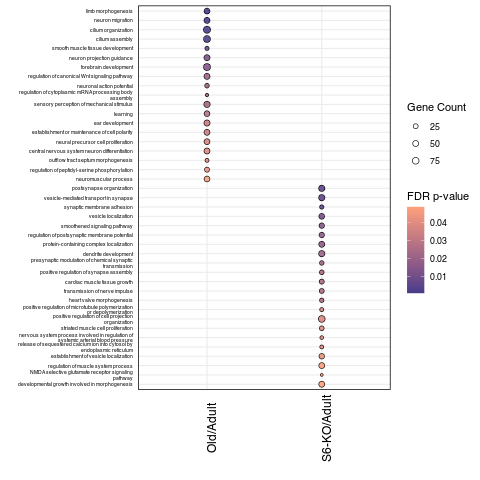

In [79]:
%%R
library(stringr)
library(tidyverse)


unique_old_terms <- unique_old_terms %>%
    mutate(GeneRatio = as.numeric(sub("/.*", "", GeneRatio)) / 
             as.numeric(sub(".*/", "", GeneRatio)))

unique_ko_terms <- unique_ko_terms %>%
    mutate(GeneRatio = as.numeric(sub("/.*", "", GeneRatio)) / 
             as.numeric(sub(".*/", "", GeneRatio)))

unique_old_terms$Group <- "Old/Adult"
unique_ko_terms$Group <- "S6-KO/Adult"

df_combined <- bind_rows(unique_old_terms, unique_ko_terms)

df_combined$Description <- str_wrap(df_combined$Description, width = 50) 

df_combined$Description <- factor(df_combined$Description, levels = rev(unique(df_combined$Description)))

ggplot(df_combined, aes(x = Group, y = Description, size = Count, fill = p.adjust)) +
  geom_point(alpha = 0.9, shape = 21, color = "black", stroke = 0.5) +  
  scale_size_continuous(range = c(1, 3)) +
  scale_fill_gradient(low = "darkslateblue", high = "lightsalmon1") +  
  labs(x = "", y = "", size = "Gene Count", fill = "FDR p-value") +  
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 5, color = 'black'),
    axis.text.x = element_text(size = 12, color = 'black', angle = 90),
    panel.border = element_rect(colour = "black", fill = NA, size = 0.7)
  )

#ggsave("/tank/projects/kashuk_sirt6_hic/supplement/Figure3_TADs_GO.pdf", width = 5, height = 7, dpi=1200)


### Supplementary: TADs size distribution

In [80]:
%%R

merged_adl <- py_eval('merged_adl')
merged_old <- py_eval('merged_old')
merged_ko <- py_eval('merged_ko')

In [81]:
%%R

adl_length <- merged_adl$end - merged_adl$start
old_length <- merged_old$end - merged_old$start
ko_length <- merged_ko$end - merged_ko$start

In [82]:
%%R

summary(adl_length)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    9999   119999   179999   222160   279999 11879999 


In [83]:
%%R

summary(old_length)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   9999  129999  189999  236853  299999 7429999 


In [84]:
%%R

summary(ko_length)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    9999   119999   189999   230894   289999 11289999 


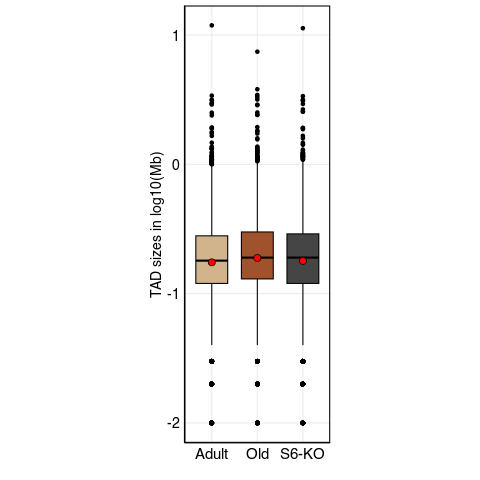

In [85]:
%%R

length <- c(adl_length, old_length, ko_length)
length <- log10(length/1000000)
type <- c(rep('Adult', length(adl_length)), rep('Old', length(old_length)), rep('S6-KO', length(ko_length)))

df <- data.frame(length, type)
summary(df)

df$type <- factor(df$type, levels=c('Adult', 'Old', 'S6-KO'))

ggplot(df, aes(type, length)) +
  geom_boxplot(aes(fill = type), width=0.7, colour='black') +
  stat_summary(fun = mean, geom = "point", shape = 21, size = 3, fill = "red", color = "black") +
  xlab('') + ylab('TAD sizes in log10(Mb)') +
  theme_minimal() +
  theme(axis.text.x   = element_text(size=15, color='black'),
        axis.text.y   = element_text(size=14, color='black'),
        axis.title.y  = element_text(size=14, color='black'),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        strip.text = element_text(size = 14, color = "black"),
        legend.position = 'none',
        aspect.ratio = 3/1
  ) +
  scale_fill_manual(values=c('tan', 'sienna', 'gray27'))

#ggsave("/tank/projects/kashuk_sirt6_hic/supplement/Figure3_TADs_size_distribution.pdf", width = 5, height = 7, dpi=1200)


In [86]:
#### Mann-Whitney U test 

In [87]:
%%R

print(wilcox.test(adl_length, old_length))
print(wilcox.test(adl_length, ko_length))
print(wilcox.test(old_length, ko_length))


	Wilcoxon rank sum test with continuity correction

data:  adl_length and old_length
W = 58609726, p-value = 7.259e-13
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  adl_length and ko_length
W = 61972123, p-value = 0.0006196
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  old_length and ko_length
W = 61393378, p-value = 0.0002965
alternative hypothesis: true location shift is not equal to 0

